# Logistic Regression with Class Weighting

The previous two notebooks fixed the imbalance by changing the **data itself**
(removing rows, or adding synthetic ones). This notebook takes a completely different
approach: it leaves the training data untouched, and instead tells the model directly
to treat mistakes on the minority class as more costly during training.

## 1. Import Libraries

No `imblearn` needed this time — everything here is standard `scikit-learn`. This is
one practical advantage of this technique: it doesn't require a separate resampling
library or an extra pipeline step.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score,
                              classification_report, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [3]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

## 2. Train/Test Split

Same 70/30 stratified split as every previous notebook, so results stay directly
comparable.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [5]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 3. Build the Pipeline with Class Weighting

The only change from the baseline model is `class_weight='balanced'`. This tells
`LogisticRegression` to automatically calculate a weight for each class, inversely
proportional to how frequent it is — so mistakes on the rare class (churn) are
penalized more heavily during training than mistakes on the common class.

Because this doesn't touch the data at all, a **regular `sklearn.pipeline.Pipeline`**
works fine here — no need for `imblearn`'s version like the previous two notebooks.

In [6]:
steps = [("preprocess", preprocessor),
         ("logistic_regression", LogisticRegression(random_state=42, class_weight='balanced'))]

pipe = Pipeline(steps)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

### 3.1 See what "balanced" actually computes *(added)*

`class_weight='balanced'` sounds like a black box — this cell reveals the actual
formula and numbers being used, using the same calculation scikit-learn performs
internally: `weight = n_samples / (n_classes × count_of_that_class)`.

In [7]:
n_samples = len(y_train)
n_classes = 2

weight_0 = n_samples / (n_classes * (y_train == 0).sum())
weight_1 = n_samples / (n_classes * (y_train == 1).sum())

print(f"Weight for Class 0 (Not Churn): {weight_0:.3f}")
print(f"Weight for Class 1 (Churn)   : {weight_1:.3f}")

Weight for Class 0 (Not Churn): 0.628
Weight for Class 1 (Churn)   : 2.454


Since churners are roughly 4x rarer than non-churners in this data, each churn mistake
gets penalized nearly 4x more heavily than a non-churn mistake during training — without
ever changing which rows the model actually sees.

In [8]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [9]:
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(3000,))

## 4. Confusion Matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1712,  677],
       [ 166,  445]])

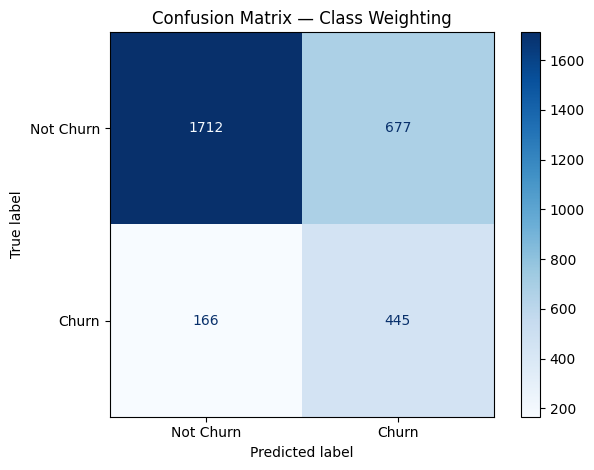

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Class Weighting")
plt.grid(False)
plt.tight_layout()
plt.show()

In [12]:
## 5. Per-Class Recall
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 (Not Churn) Recall: {class0_recall:.2f}")
print(f"Class 1 (Churn) Recall: {class1_recall:.2f}")

Class 0 (Not Churn) Recall: 0.72
Class 1 (Churn) Recall: 0.73


## 5. Overall Metrics

In [13]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.72
Precision : 0.40
Recall    : 0.73
F1 Score  : 0.51


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      2389
           1       0.40      0.73      0.51       611

    accuracy                           0.72      3000
   macro avg       0.65      0.72      0.66      3000
weighted avg       0.81      0.72      0.74      3000



## 6. Predicted Probabilities and Threshold-Independent Metrics

In [15]:
y_prob = pipe.predict_proba(X_test)[:, 1]
y_prob

array([0.16754273, 0.39546699, 0.54631766, ..., 0.72007137, 0.55804974,
       0.16267703], shape=(3000,))

In [16]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.79
PR-AUC Score : 0.50


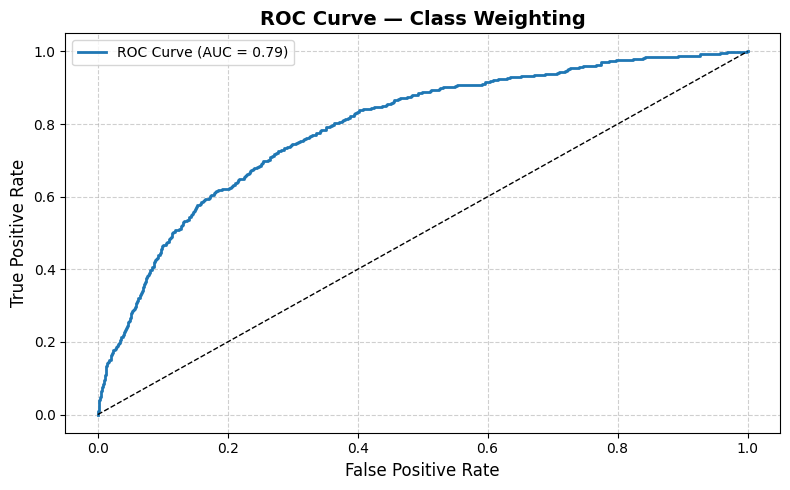

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Class Weighting", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

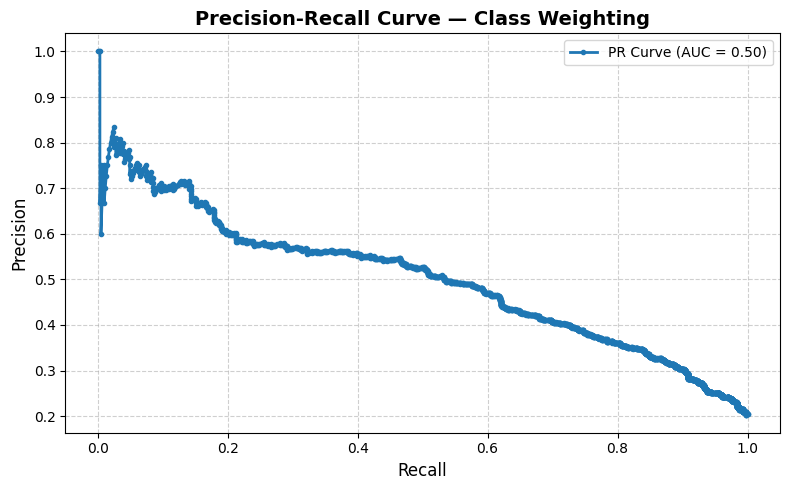

In [18]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — Class Weighting", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Comparison: All Techniques So Far *(added)*

In [19]:
comparison = pd.DataFrame({
    "Baseline":      [0.81, 0.62, 0.19, 0.29, 0.79, 0.51],
    "UnderSampling": [0.72, 0.40, 0.73, 0.52, 0.79, 0.50],
    "SMOTE":         [0.72, 0.40, 0.72, 0.52, 0.79, 0.50],
    "ClassWeight": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,Baseline,UnderSampling,SMOTE,ClassWeight
Accuracy,0.81,0.72,0.72,0.72
Precision,0.62,0.40,0.40,0.40
Recall,0.19,0.73,0.72,0.73
F1 Score,0.29,0.52,0.52,0.51
ROC-AUC,0.79,0.79,0.79,0.79
PR-AUC,0.51,0.50,0.50,0.50


## 8. Summary

- **Nearly identical results to UnderSampling and SMOTE** — recall ~0.73, precision
  ~0.40, ROC-AUC ~0.79 across all three techniques.
- **This convergence is the real finding of this notebook.** Three fundamentally
  different strategies — deleting data, generating synthetic data, and reweighting
  errors — all landed in almost the same place. That's strong evidence the model's
  performance ceiling here is set by the **features themselves**, not by which
  imbalance-handling trick is used. No resampling or reweighting method can invent
  predictive signal that isn't already present in `CreditScore`, `Age`, `Balance`, etc.
- **Practical advantage of Class Weighting over the other two:** no extra library, no
  extra pipeline step, no risk of data leakage from misusing a resampler, and no
  synthetic/duplicated data to reason about. If you need to justify one single approach
  to a stakeholder, this is often the simplest to explain and defend.

The final notebook in this series tries **ADASYN** — a refinement of SMOTE that focuses
extra synthetic examples specifically on the *hardest* churn cases to classify, rather
than spreading them evenly. Whether that focus produces any real improvement over the
three near-identical results above is the open question it will answer.